In [1]:
!pwd
%whos

/Users/nesh/Documents/Repositories/icecontinuum/Sample code/Figure 4. Zero-dimensional limit cycles
Interactive namespace is empty.


In [2]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams
import time
from copy import copy as dup
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from pint import UnitRegistry; AssignQuantity = UnitRegistry().Quantity
from importlib import reload
from matplotlib.gridspec import GridSpec

# My modules
import sys; sys.path.append('..')
import importlib  # Import the importlib module
import QLCstuff as QLC
import f90nml

In [3]:
# Graphics parameters
%matplotlib inline
ticklabelsize = 11
fontsize = 15
linewidth = 2

### Three trajectories deviating a little from the default (and all 0-dimensional)


Using parameter file ../GI parameters - Table 1.nml ...
sigmaI_corner = 22 percent
sigma0 = 20 percent
c_r = 0.2 percent
Nbar 1
Nstar 0.1
h_layer = 0.37 nanometer
D = 0.0002 micrometer ** 2 / microsecond
nu_kin = 0.264 / microsecond
L = 50 micrometer
nx (crystal) = 501
t_eq = 1.5 microsecond
Spacing of points on the ice surface = 0.20000000000000284 micrometer
omega_kin = 0.396 dimensionless

Using parameter file RT parameters for 0D.nml ...
runtime = 200 microsecond
odemethod = RK45
This is a run from time 0.0 millisecond to 0.2 millisecond
dt = 0.5012531328320802 microsecond
sigmaI_corner 0.22 dimensionless
sigma0 0.2 dimensionless
nu_kin 0.264 / microsecond
t_eq 1.5 microsecond
10 % done
20 % done
30 % done
40 % done
50 % done
60 % done
70 % done
80 % done
90 % done
100% done
10 % done
20 % done
30 % done
40 % done
50 % done
60 % done
70 % done
80 % done
90 % done
100% done
10 % done
20 % done
30 % done
40 % done
50 % done
60 % done
70 % done
80 % done
90 % done
100% done


/Users/nesh/anaconda3/lib/python3.10/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


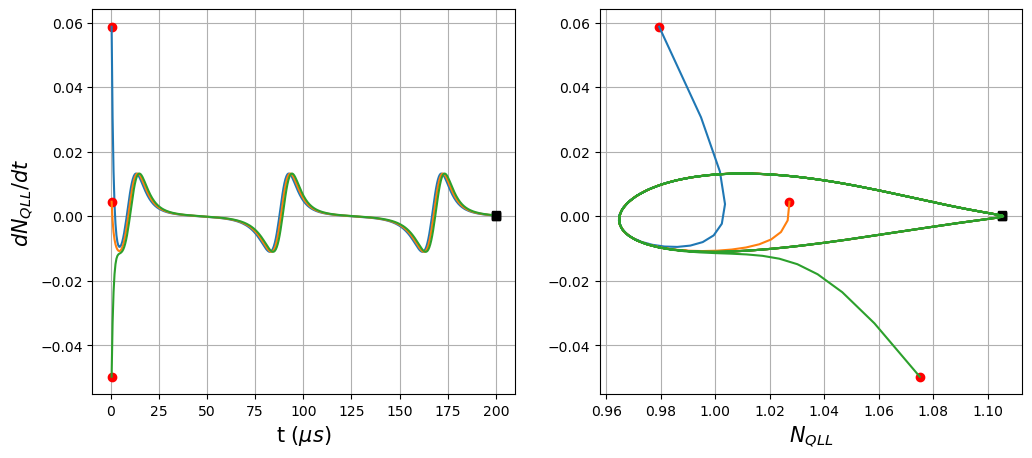

In [5]:
GIfile =                    '../GI parameters - Table 1.nml'
figurename_0d_limit_cycle = 'Figure - zero-dimensional limit cycle.png'

sigmaI_corner, sigma0, c_r, sigmaI_QLC, Nbar, Nstar, h_layer, D, nu_kin, L, nx_crystal, t_eq, x_QLC, DoverL2pi2, Doverdeltax2 = \
    QLC.get_system_parameters(GIfile, AssignQuantity)

RTfile = "RT parameters for 0D.nml"
odemethod, tkeep_0Darr, Ntot_init_1D, NQLL_init_1D = \
    QLC.get_runtime_parameters(RTfile, nx_crystal, Nstar, Nbar, AssignQuantity)

# Unit conversions to forms assumed by subsequent code
sigmaI_corner.ito('dimensionless')
print('sigmaI_corner', sigmaI_corner)

sigma0.ito('dimensionless')
print('sigma0',sigma0)

nu_kin.ito('1/microsecond')
print('nu_kin', nu_kin)

t_eq.ito('microsecond')
print('t_eq', t_eq)

startfactor_range = np.linspace(0.95,1.1,3)
fig = plt.figure(figsize=(12,5))

for startfactor in startfactor_range:
    
    # Initialize as a pre-equilibrated layer of liquid over ice
    Ntot_init_0D = Ntot_init_1D[0]
    NQLL_init_0D = NQLL_init_1D[0]*startfactor

    # Run the trajectory
    Ntotkeep_0D, NQLLkeep_0D = QLC.run_f0d( \
            NQLL_init_0D,Ntot_init_0D,tkeep_0Darr,\
            Nbar, Nstar, sigma0, nu_kin, t_eq, sigmaI_corner,\
            AssignQuantity,\
            verbose=0)
    Nicekeep_0D = Ntotkeep_0D - NQLLkeep_0D

    # 1st derivative
    increment = 10
    back_from_end1 = 25
    dt = tkeep_0Darr[1]-tkeep_0Darr[0]
    dNQLL_dt = np.diff(NQLLkeep_0D)/dt
    back_from_end2 = back_from_end1*2
    back_from_end3 = back_from_end1*3
    back_from_end4 = back_from_end1*4
    fwd_from_start1 = 25
    fwd_from_start2 = fwd_from_start1*2
    fwd_from_start3 = fwd_from_start1*3

    plt.subplot(1,2,2)
    plt.plot(NQLLkeep_0D[1],dNQLL_dt[0],'or',label='start')
    plt.plot(NQLLkeep_0D[-1],dNQLL_dt[-1],'sk',label='end')
    plt.plot(NQLLkeep_0D[1:],dNQLL_dt)
    plt.xlabel(r'$N_{QLL} $',fontsize=fontsize)
    plt.grid(True)
    
    plt.subplot(1,2,1)
    plt.plot(tkeep_0Darr[1],dNQLL_dt[0],'or',label='start')
    plt.plot(tkeep_0Darr[1:],dNQLL_dt)
    plt.plot(tkeep_0Darr[-1],dNQLL_dt[-1],'sk',label='end')
    plt.ylabel(r'$dN_{QLL}/dt$',fontsize=fontsize)
    plt.xlabel(r't ($\mu s$)',fontsize=fontsize)
    plt.grid(True)

fig.savefig(figurename_0d_limit_cycle, dpi=200)